<a href="https://colab.research.google.com/github/AdarkarRavaji2004/CSL701-CS01_Machine-Learning-Lab/blob/main/Experiments/ML_Experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Ravaji Parshuram Adarkar | Roll No. : CS01

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


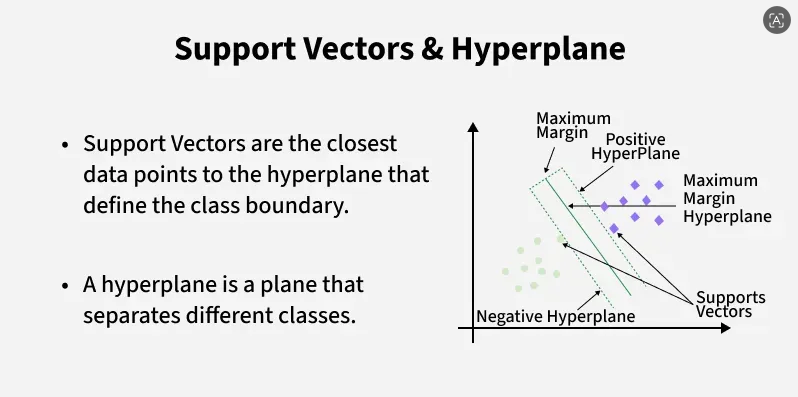
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [2]:
# Task 1: Import Libraries and Load Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Kaggle Iris dataset
df = pd.read_csv('Iris.csv')

# Display first 5 rows
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


# Task 2: Explore the Dataset

In [3]:
# Task 2: Explore the Dataset

# Display shape
print("Dataset Shape:")
print(df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns)

# Display first 5 rows
print("\nFirst 5 Rows:")
print(df.head())

# Display dataset information
print("\nDataset Information:")
df.info()

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Display class distribution
print("\nSpecies Distribution:")
print(df['Species'].value_counts())

Dataset Shape:
(150, 6)

Column Names:
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

First 5 Rows:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm

# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [4]:
# Task 3: Select Features and Target

# Remove Id column
df = df.drop('Id', axis=1)

# Select remaining four features
X = df[
    [
        'SepalLengthCm',
        'SepalWidthCm',
        'PetalLengthCm',
        'PetalWidthCm'
    ]
]

# Select target
y = df['Species']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

Target:
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [5]:
# Task 4: Split and Scale the Data

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Convert species names to numbers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Create StandardScaler
scaler = StandardScaler()

# Scale training data
X_train_scaled = scaler.fit_transform(X_train)

# Scale testing data
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

print("\nClasses:")
print(label_encoder.classes_)

Training data shape: (120, 4)
Testing data shape: (30, 4)

Classes:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [6]:
# Task 5: Implement Linear SVM

from sklearn.svm import SVC

# Create Linear SVM model
svm_model = SVC(kernel='linear')

# Train the model
svm_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM model trained successfully!")

print("\nPredictions:")
print(y_pred_svm)

SVM model trained successfully!

Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


In [7]:
# Task 6: Evaluate SVM

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:")
print(accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)

print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=label_encoder.classes_
    )
)

SVM Accuracy:
1.0

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

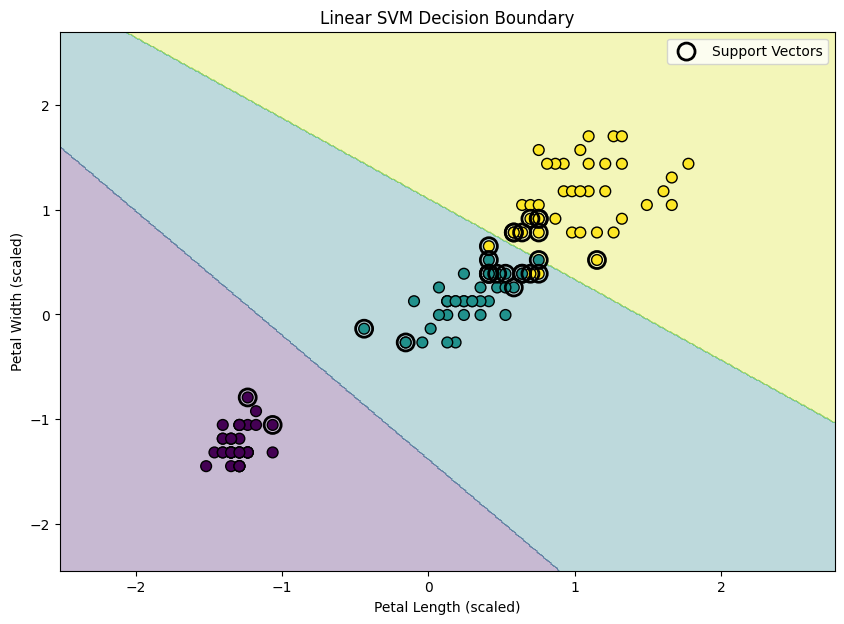

In [8]:
# Task 7: Visualize SVM Decision Boundary

# Select only Petal Length and Petal Width
X_2d = df[
    [
        'PetalLengthCm',
        'PetalWidthCm'
    ]
]

# Target
y_2d = y_encoded

# Split the 2D data
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d,
    y_2d,
    test_size=0.2,
    random_state=42,
    stratify=y_2d
)

# Scale the 2D data
scaler_2d = StandardScaler()

X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

# Train Linear SVM
svm_2d = SVC(kernel='linear')
svm_2d.fit(X_train_2d_scaled, y_train_2d)

# Create mesh grid
x_min = X_train_2d_scaled[:, 0].min() - 1
x_max = X_train_2d_scaled[:, 0].max() + 1

y_min = X_train_2d_scaled[:, 1].min() - 1
y_max = X_train_2d_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Predict grid points
Z = svm_2d.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(10, 7))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3
)

# Plot training data
plt.scatter(
    X_train_2d_scaled[:, 0],
    X_train_2d_scaled[:, 1],
    c=y_train_2d,
    edgecolors='k',
    s=60
)

# Highlight support vectors
plt.scatter(
    svm_2d.support_vectors_[:, 0],
    svm_2d.support_vectors_[:, 1],
    s=150,
    facecolors='none',
    edgecolors='black',
    linewidths=2,
    label='Support Vectors'
)

plt.xlabel('Petal Length (scaled)')
plt.ylabel('Petal Width (scaled)')
plt.title('Linear SVM Decision Boundary')
plt.legend()

plt.show()

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

In [9]:
# Task 8: Normal Linear Classification Boundary

from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = LogisticRegression(max_iter=200)

# Train model
logistic_model.fit(
    X_train_2d_scaled,
    y_train_2d
)

# Make predictions
y_pred_logistic = logistic_model.predict(
    X_test_2d_scaled
)

print("Logistic Regression model trained successfully!")

print("\nPredictions:")
print(y_pred_logistic)

Logistic Regression model trained successfully!

Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]


# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

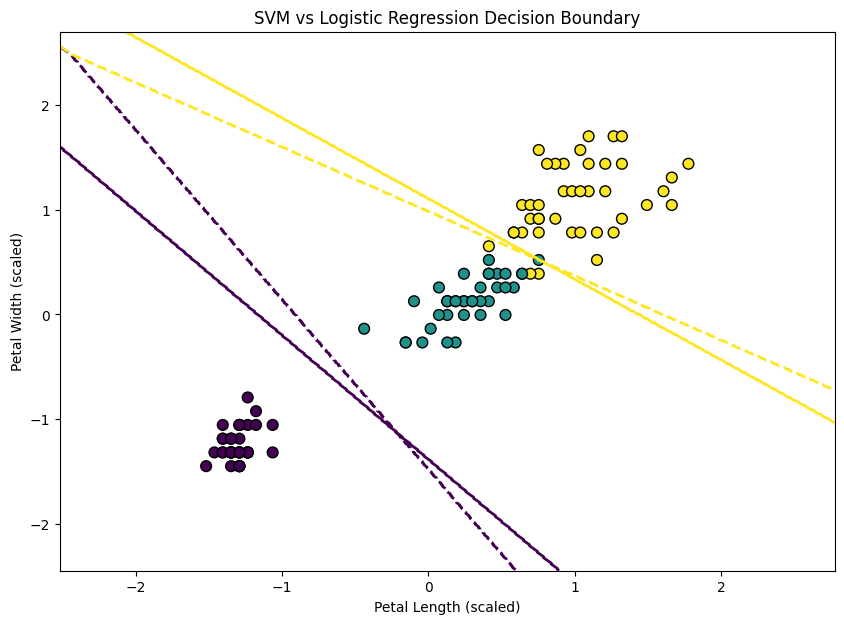

In [10]:
# Task 9: Compare SVM and Logistic Regression Boundary

# Create mesh grid
x_min = X_train_2d_scaled[:, 0].min() - 1
x_max = X_train_2d_scaled[:, 0].max() + 1

y_min = X_train_2d_scaled[:, 1].min() - 1
y_max = X_train_2d_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Create grid
grid = np.c_[xx.ravel(), yy.ravel()]

# Predict using SVM
Z_svm = svm_2d.predict(grid)

# Predict using Logistic Regression
Z_logistic = logistic_model.predict(grid)

# Reshape predictions
Z_svm = Z_svm.reshape(xx.shape)
Z_logistic = Z_logistic.reshape(xx.shape)

# Plot
plt.figure(figsize=(10, 7))

# SVM boundary
plt.contour(
    xx,
    yy,
    Z_svm,
    levels=[0.5, 1.5],
    linewidths=2
)

# Logistic Regression boundary
plt.contour(
    xx,
    yy,
    Z_logistic,
    levels=[0.5, 1.5],
    linestyles='--',
    linewidths=2
)

# Plot training points
plt.scatter(
    X_train_2d_scaled[:, 0],
    X_train_2d_scaled[:, 1],
    c=y_train_2d,
    edgecolors='k',
    s=60
)

plt.xlabel('Petal Length (scaled)')
plt.ylabel('Petal Width (scaled)')
plt.title('SVM vs Logistic Regression Decision Boundary')

plt.show()

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

In [11]:
# Task 10: Compare Performance

# Calculate SVM accuracy
svm_accuracy = accuracy_score(
    y_test_2d,
    svm_2d.predict(X_test_2d_scaled)
)

# Calculate Logistic Regression accuracy
logistic_accuracy = accuracy_score(
    y_test_2d,
    y_pred_logistic
)

print("======================================")
print("       PERFORMANCE COMPARISON")
print("======================================")

print("\nLinear SVM Accuracy:")
print(svm_accuracy)

print("\nLogistic Regression Accuracy:")
print(logistic_accuracy)


# SVM Confusion Matrix
print("\n======================================")
print("SVM CONFUSION MATRIX")
print("======================================")

print(
    confusion_matrix(
        y_test_2d,
        svm_2d.predict(X_test_2d_scaled)
    )
)


# Logistic Regression Confusion Matrix
print("\n======================================")
print("LOGISTIC REGRESSION CONFUSION MATRIX")
print("======================================")

print(
    confusion_matrix(
        y_test_2d,
        y_pred_logistic
    )
)


# SVM Classification Report
print("\n======================================")
print("SVM CLASSIFICATION REPORT")
print("======================================")

print(
    classification_report(
        y_test_2d,
        svm_2d.predict(X_test_2d_scaled),
        target_names=label_encoder.classes_
    )
)


# Logistic Regression Classification Report
print("\n======================================")
print("LOGISTIC REGRESSION CLASSIFICATION REPORT")
print("======================================")

print(
    classification_report(
        y_test_2d,
        y_pred_logistic,
        target_names=label_encoder.classes_
    )
)

       PERFORMANCE COMPARISON

Linear SVM Accuracy:
0.9333333333333333

Logistic Regression Accuracy:
0.9333333333333333

SVM CONFUSION MATRIX
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

LOGISTIC REGRESSION CONFUSION MATRIX
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

SVM CLASSIFICATION REPORT
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30


LOGISTIC REGRESSION CLASSIFICATION REPORT
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0

# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.